In [1]:
import matplotlib.pyplot as plt

In [2]:
from cea.signal1D import*
from cea.general import*
from cea.data_loader import*
from cea.output import*
from cea.signal2D import*

# Visualisation

In [3]:
data, labels = load_RTCEA("data/RTCEA_bimode.hdf5")
atwood = create_atwood_dic(labels)

idxs = atwood[0.3]
sim = data[idxs,:,:] 
time = labels[idxs,1]


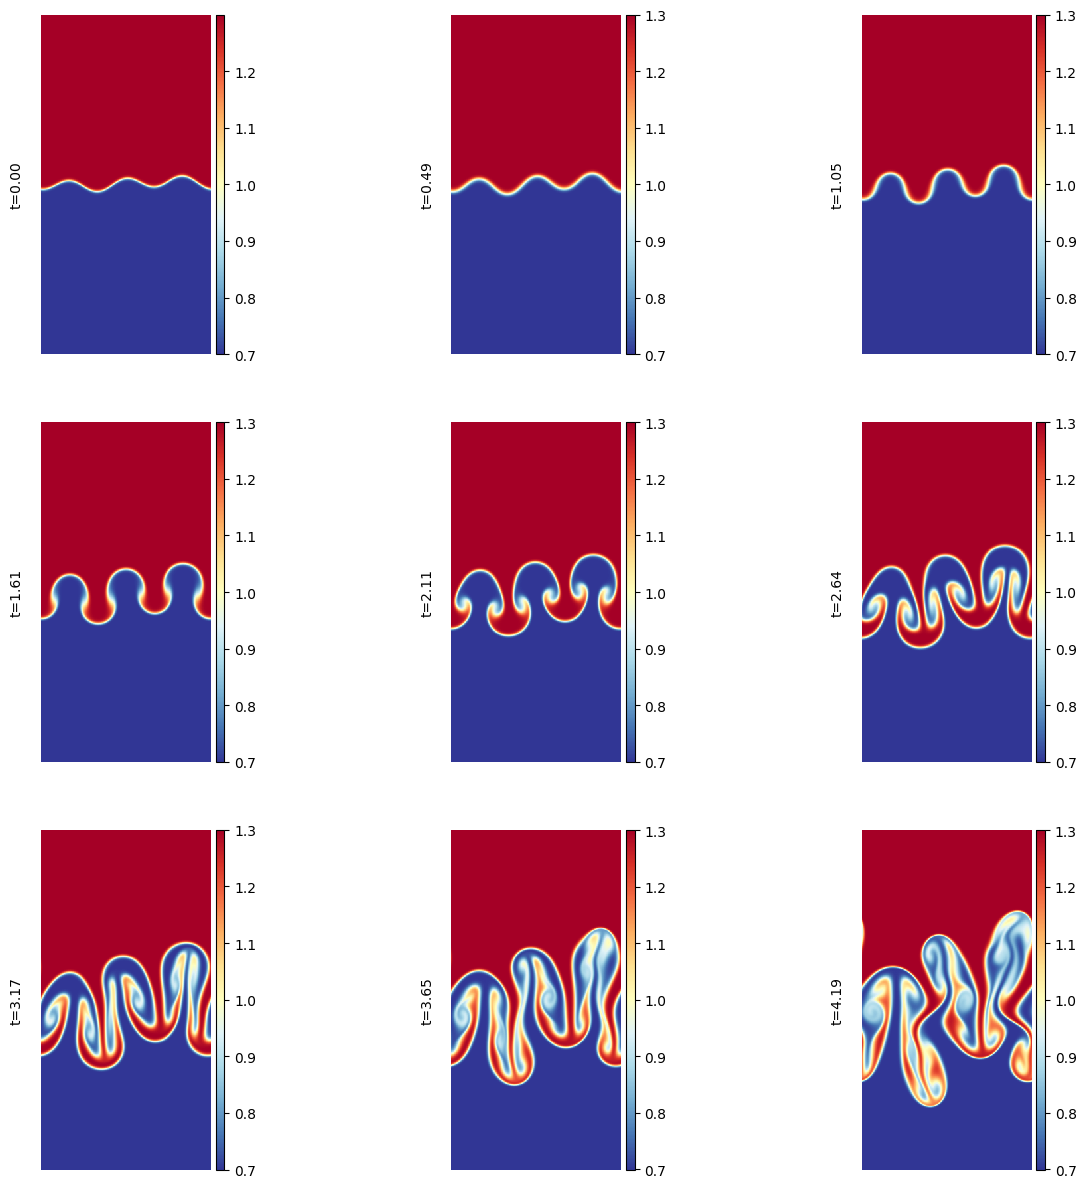

In [4]:
plot_sim_2d(sim, time)

(114, 512, 512)


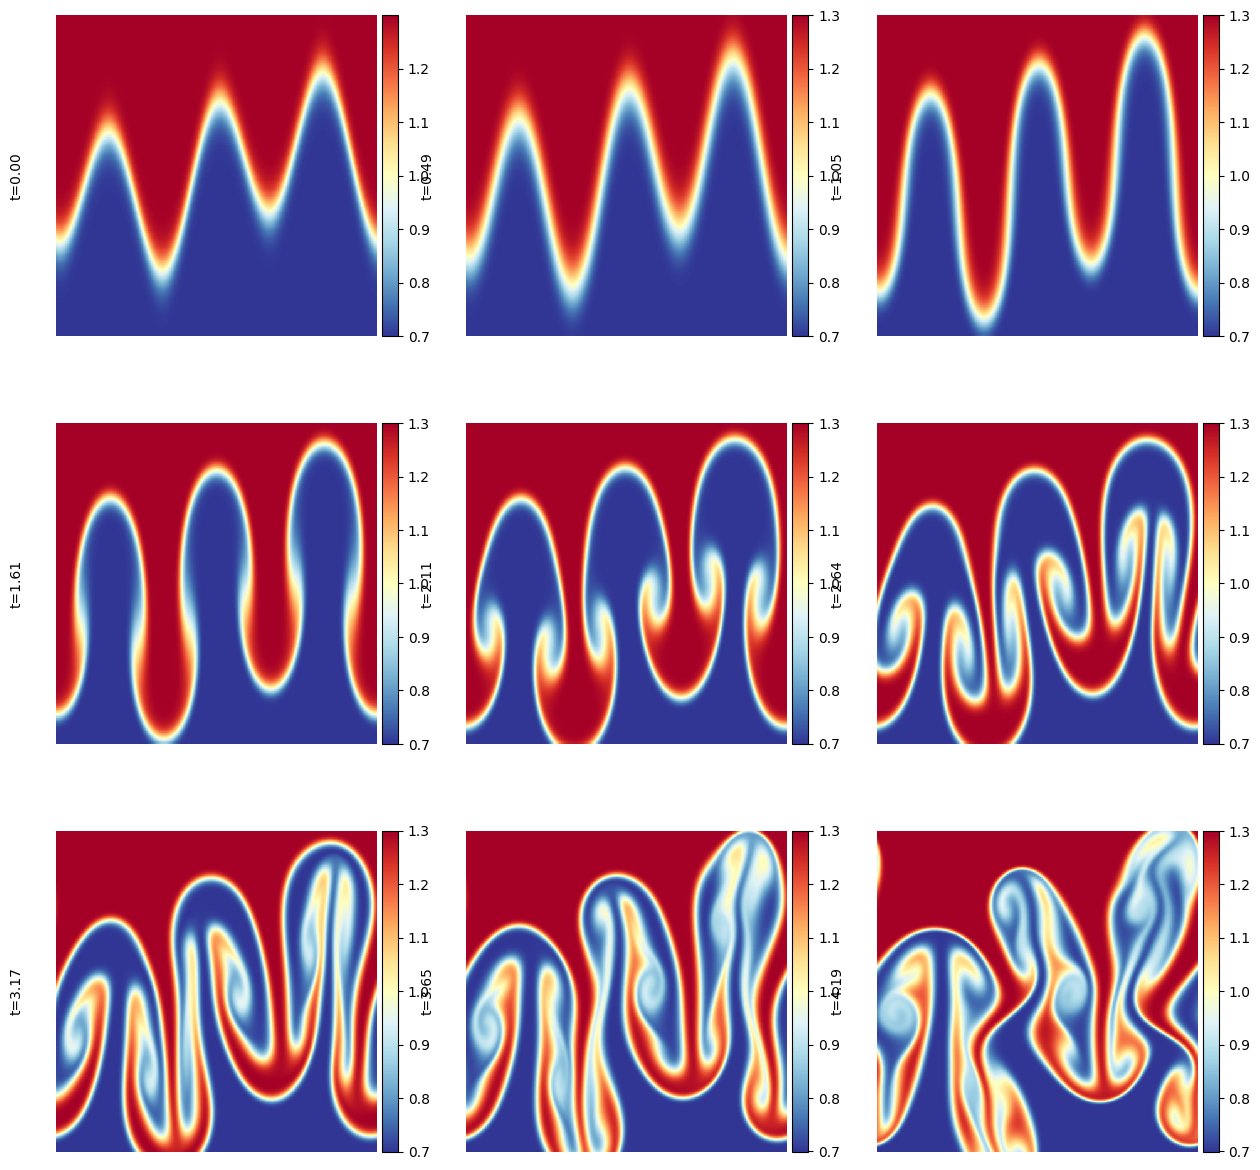

In [ ]:
simm, ti = sim_normalise_2d(data, labels, atwood=0.3, marge=0.15, square=True)
plot_sim_2d(simm, ti)
print(simm.shape)

In [ ]:
def sim_normalise_2d(data, labels, marge=0, square=False):
    """
    Normalise et recadre des simulations 2D pour un nombre d'Atwood donné.

    La fonction :
    - sélectionne les simulations correspondant à un Atwood
    - normalise un paramètre de longueur
    - applique un masquage spatial
    - redimensionne les images

    Args:
        data (ndarray): simulations 3D (n, h, w)
        labels (ndarray): labels associés
        atwood (float): valeur du nombre d'Atwood

    Returns:
        tuple:
            - sim_norm (ndarray): simulations normalisées
            - t (ndarray): temps associé aux simulations
    """
    # try:
    #     a = create_atwood_dic(labels)
    #     idxs = a[atwood]
    # except Exception:
    #     print("Aucun Atwood correspondant dans les données!")
    #     return

    t = labels[:, 1]
    L = labels[:, 2]
    L_norm = (L - L.min()) / (L.max() - L.min())

    sim = data[:, :, :]

    if square:
        # Choisis la taille carrée cible (par exemple, la plus grande dimension)
        target_size = max(sim.shape[1], sim.shape[2])
        sim_norm = np.zeros((sim.shape[0], target_size, target_size))
    else:
        sim_norm = np.zeros_like(sim)

    for i in range(sim.shape[0]):
        simi = sim[i, :, :]

        cropped = mask2d(
            simi,
            sim.shape[1] * 2,
            int(sim.shape[2] * L_norm[i] + marge * sim.shape[2]),
            True
        )

        if square:
            # Redimensionne en carré
            sim_norm[i] = resize2d(cropped, target_size, target_size)
        else:
            sim_norm[i] = resize2d(cropped, simi.shape[1], simi.shape[0])


    return sim_norm #, t








data_norm = sim_normalise_2d(data, labels, marge=0.15, square=True)
atwood = create_atwood_dic(labels)

idxs = atwood[0.3]
sim2 = data[idxs,:,:] 
time2 = labels[idxs,1]

plot_sim_2d(sim2, time2)
print(sim2.shape)
